# Csak releváns listák és dalok kimentése

In [ ]:
import h5py
import pickle
from gensim.models import Word2Vec
from tqdm import tqdm

H5_PATH = "../Dataset/spotify_dataset_compressed.h5"
W2V_PATH = "../Models/song2vec.model"
OUTPUT_PATH = "../Models/filtered_playlists_indices.pkl"
MIN_LENGTH = 5

print("1. Word2Vec szótár betöltése...")
w2v_model = Word2Vec.load(W2V_PATH)

# Ez egy nagyon gyors szótár (Dictionary), ami a Spotify URI-t a mátrix sorszámára (0-372432) alakítja
# Így a Keras Embedding rétege rögtön tudja, melyik sort kell kiolvasnia!
uri_to_index = w2v_model.wv.key_to_index

clean_playlists = []

print("2. Lejátszási listák szűrése és konvertálása...")
with h5py.File(H5_PATH, "r") as hf:
    pids = hf["playlist_tracks/pid"][:]
    uris = hf["playlist_tracks/track_uri"][:]

    current_pid = None
    current_sequence = []

    for i in tqdm(range(len(pids))):
        pid = pids[i]
        uri = uris[i]
        if isinstance(uri, bytes):
            uri = uri.decode('utf-8')

        if current_pid is None:
            current_pid = pid

        if pid == current_pid:
            # Csak akkor adjuk hozzá, ha benne van a Word2Vec szótárban!
            # És RÖGTÖN az indexét (integer) mentjük el a string helyett!
            if uri in uri_to_index:
                current_sequence.append(uri_to_index[uri])
        else:
            # PID megváltozott, vizsgáljuk meg az eddigi listát
            if len(current_sequence) >= MIN_LENGTH:
                clean_playlists.append(current_sequence)

            # Új lista kezdése
            current_sequence = []
            if uri in uri_to_index:
                current_sequence.append(uri_to_index[uri])
            current_pid = pid

    # Az utolsó listát is ellenőrizzük a ciklus után
    if len(current_sequence) >= MIN_LENGTH:
        clean_playlists.append(current_sequence)

print(f"\n✅ Szűrés kész! Eredeti listák száma: 1 000 000")
print(f"✅ Megmaradt, tiszta listák száma: {len(clean_playlists)}")

print("3. Mentés Pickle fájlba...")
with open(OUTPUT_PATH, "wb") as f:
    pickle.dump(clean_playlists, f)

print(f"🎉 Mentés sikeres: {OUTPUT_PATH}")

1. Word2Vec szótár betöltése...
2. Lejátszási listák szűrése és konvertálása...


100%|██████████| 66346428/66346428 [01:16<00:00, 872874.28it/s]



✅ Szűrés kész! Eredeti listák száma: 1 000 000
✅ Megmaradt, tiszta listák száma: 991795
3. Mentés Pickle fájlba...
🎉 Mentés sikeres: ../Models/filtered_playlists_indices.pkl


# CNN vektorok kimentése

## Mel+Chroma+Tempo

In [ ]:
import os
import h5py
import pickle
import numpy as np
from tqdm import tqdm
import tensorflow as tf

# --- ÚTVONALAK ---
H5_PATH = "/content/drive/MyDrive/Diplomamunka/spotify_dataset_compressed.h5"
CNN_MODEL_PATH = "/content/drive/MyDrive/Diplomamunka/spotify_cnn_model.keras"
CNN_DICT_PATH = "/content/drive/MyDrive/cnn_vectors.pkl"

# --- EGYÉDI OBJEKTUMOK (A betöltéshez kellenek) ---
def cosine_loss(y_true, y_pred):
    return tf.keras.losses.cosine_similarity(y_true, y_pred)

class L2NormLayer(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super(L2NormLayer, self).__init__(**kwargs)
    def call(self, inputs):
        return tf.nn.l2_normalize(inputs, axis=-1)

# 1. Modell betöltése
print("🧠 CNN Modell betöltése...")
cnn_model = tf.keras.models.load_model(
    CNN_MODEL_PATH,
    custom_objects={'cosine_loss': cosine_loss, 'L2NormLayer': L2NormLayer}
)

cnn_vectors_dict = {}

# 2. Feldolgozás
with h5py.File(H5_PATH, "r") as hf:
    uris = hf["ml/track_uri"][:]
    total_tracks = len(uris)

    print(f"📊 HDF5-ben talált dalok: {total_tracks}")

    for i in tqdm(range(total_tracks), desc="Vektorok kinyerése"):
        try:
            # Spektrogramok beolvasása (Chroma és Tempo is!)
            m = hf["spectrograms/mel"][i]

            # Ellenőrizzük, hogy nem csupa nulla-e (ez szűri ki az 1 hibás dalt)
            if np.all(m == 0):
                continue

            c = hf["spectrograms/chroma"][i]
            t = hf["spectrograms/tempogram"][i]

            # Dimenziók beállítása a modellnek (1, H, W, 1)
            m_in = m[np.newaxis, ..., np.newaxis].astype(np.float32)
            c_in = c[np.newaxis, ..., np.newaxis].astype(np.float32)
            t_in = t[np.newaxis, ..., np.newaxis].astype(np.float32)

            # Predikció
            vec = cnn_model.predict([m_in, c_in, t_in], verbose=0)[0]

            # URI dekódolása és mentése
            uri = uris[i].decode('utf-8') if isinstance(uris[i], bytes) else uris[i]
            cnn_vectors_dict[uri] = vec

            # Időnkénti memóriaürítés a TF-nek
            if i % 1000 == 0:
                tf.keras.backend.clear_session()

        except Exception as e:
            print(f"\n⚠️ Hiba az indexnél {i}: {e}")
            continue

# 3. Mentés
print(f"\n💾 Mentés ide: {CNN_DICT_PATH}")
with open(CNN_DICT_PATH, 'wb') as f:
    pickle.dump(cnn_vectors_dict, f)

print(f"✅ KÉSZ! Összesen {len(cnn_vectors_dict)} valid vektor elmentve.")

🧠 CNN Modell betöltése...
📊 HDF5-ben talált dalok: 27052


Vektorok kinyerése: 100%|██████████| 27052/27052 [1:02:05<00:00,  7.26it/s]



💾 Mentés ide: /content/drive/MyDrive/cnn_vectors.pkl
✅ KÉSZ! Összesen 25510 valid vektor elmentve.


📂 Vektorok betöltése...
✅ Betöltve: 25510 dal. Vektorok alakja: (25510, 400)
⚖️ Vektorok L2 normalizálása a pontos távolságméréshez...
🤖 K-Means klaszterezés indítása (15 klaszter)...
💾 Klaszter besorolások elmentve ide: ../Models/cnn_clusters.csv
🎨 t-SNE 2D projekció számítása 5000 véletlenszerű dalon (ez eltarthat 1-2 percig)...


C:\Users\Béres Gábor\AppData\Local\Temp\ipykernel_17056\1251953172.py:81: UserWarning: Glyph 127925 (\N{MUSICAL NOTE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Béres Gábor\music_recommender\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127925 (\N{MUSICAL NOTE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


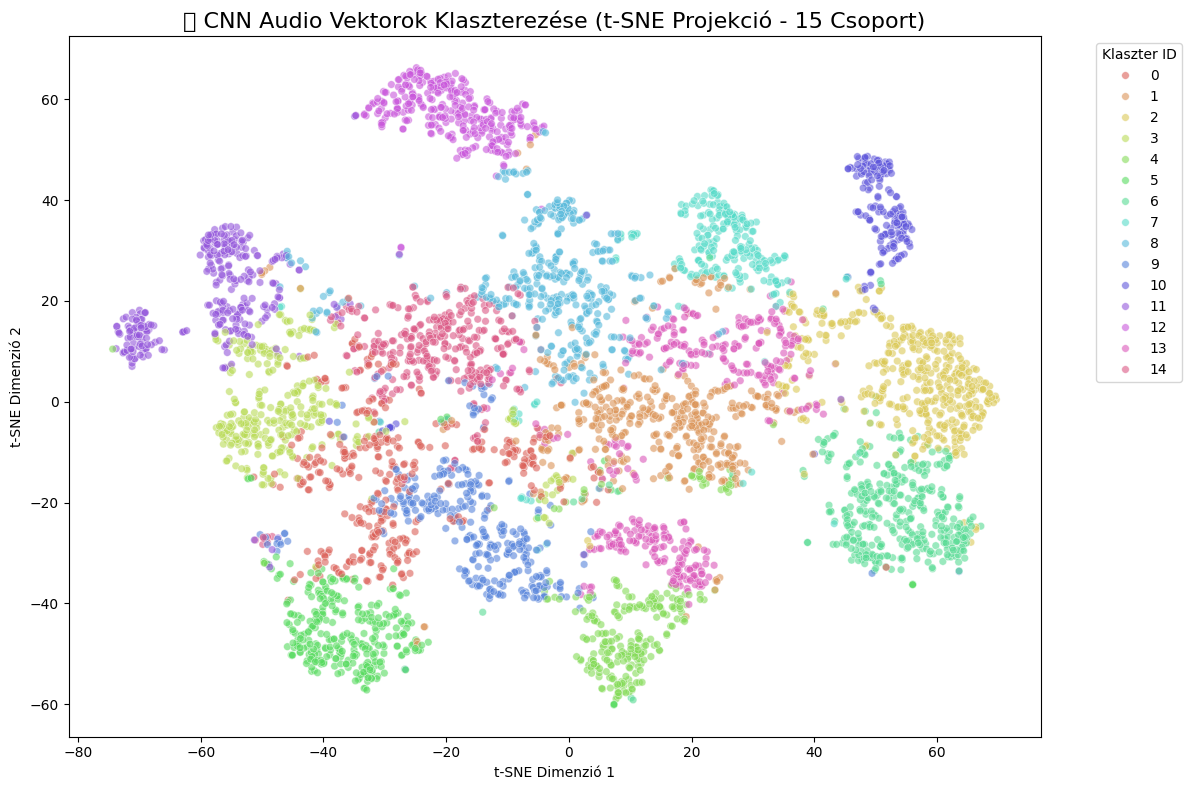

✨ KÉSZ! Nézd meg a generált ábrát és a CSV fájlt!


In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize
from sklearn.manifold import TSNE
import seaborn as sns

# ==========================================
# 1. ÚTVONALAK BEÁLLÍTÁSA
# ==========================================
CNN_VECTORS_PATH = "../Models/cnn_vectors.pkl" # Állítsd be a sajátodra!
OUTPUT_CSV_PATH = "../Models/cnn_clusters.csv"
NUM_CLUSTERS = 15 # Hány zenei "műfajt/hangulatot" keressen a gép?

# ==========================================
# 2. ADATOK BETÖLTÉSE ÉS ELŐKÉSZÍTÉSE
# ==========================================
print("📂 Vektorok betöltése...")
with open(CNN_VECTORS_PATH, "rb") as f:
    cnn_vectors = pickle.load(f)

# Szétválasztjuk az azonosítókat és a vektorokat mátrixba
uris = list(cnn_vectors.keys())
vectors = np.array(list(cnn_vectors.values()))

print(f"✅ Betöltve: {len(uris)} dal. Vektorok alakja: {vectors.shape}")

# KULCSLÉPÉS: L2 Normalizálás (Mivel Cosine Loss-t használtunk!)
print("⚖️ Vektorok L2 normalizálása a pontos távolságméréshez...")
vectors_normalized = normalize(vectors, axis=1, norm='l2')

# ==========================================
# 3. KLASZTEREZÉS (K-MEANS)
# ==========================================
print(f"🤖 K-Means klaszterezés indítása ({NUM_CLUSTERS} klaszter)...")
# A n_init='auto' gyorsítja a folyamatot az újabb scikit-learn verziókban
kmeans = KMeans(n_clusters=NUM_CLUSTERS, random_state=42, n_init=10)
clusters = kmeans.fit_predict(vectors_normalized)

# Mentsük el egy Pandas DataFrame-be, hogy könnyen elemezhető legyen
df_clusters = pd.DataFrame({
    'track_uri': uris,
    'cluster_id': clusters
})
df_clusters.to_csv(OUTPUT_CSV_PATH, index=False)
print(f"💾 Klaszter besorolások elmentve ide: {OUTPUT_CSV_PATH}")

# ==========================================
# 4. VIZUALIZÁCIÓ (t-SNE 2D VETÍTÉS)
# ==========================================
# A t-SNE nagyon lassú tud lenni százezer dalon, ezért csak egy 5000 fős mintát rajzolunk ki!
SAMPLE_SIZE = min(5000, len(uris))
print(f"🎨 t-SNE 2D projekció számítása {SAMPLE_SIZE} véletlenszerű dalon (ez eltarthat 1-2 percig)...")

# Véletlen minta kiválasztása
sample_indices = np.random.choice(len(uris), SAMPLE_SIZE, replace=False)
vectors_sample = vectors_normalized[sample_indices]
clusters_sample = clusters[sample_indices]

# Dimenziócsökkentés 400-ról 2-re
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
vectors_2d = tsne.fit_transform(vectors_sample)

# Ábra megrajzolása
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x=vectors_2d[:, 0], 
    y=vectors_2d[:, 1],
    hue=clusters_sample,
    palette=sns.color_palette("hls", NUM_CLUSTERS),
    legend="full",
    alpha=0.6,
    s=30
)
plt.title(f"🎵 CNN Audio Vektorok Klaszterezése (t-SNE Projekció - {NUM_CLUSTERS} Csoport)", fontsize=16)
plt.xlabel("t-SNE Dimenzió 1")
plt.ylabel("t-SNE Dimenzió 2")
plt.legend(title='Klaszter ID', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print("✨ KÉSZ! Nézd meg a generált ábrát és a CSV fájlt!")

In [2]:
import h5py
import pandas as pd
import numpy as np

# ==========================================
# 1. ÚTVONALAK BEÁLLÍTÁSA
# ==========================================
CLUSTERS_CSV_PATH = "../Models/cnn_clusters.csv"     # Amit a t-SNE kód generált
H5_METADATA_PATH = "../Dataset/spotify_dataset_compressed.h5"  # A fenti kódod kimenete

# ==========================================
# 2. METAADATOK KINYERÉSE A HDF5-BŐL
# ==========================================
print("📂 Metaadatok kinyerése a HDF5 fájlból...")

with h5py.File(H5_METADATA_PATH, "r") as hf:
    # Beolvassuk a memóriába az URI-kat és az előadókat
    raw_uris = hf['tracks/track_uri'][:]
    raw_artists = hf['tracks/artist_name'][:]

# A HDF5 bytes formátumban tárolhatja a stringeket (b'szöveg'), ezt dekódoljuk tiszta szöveggé
uris = [u.decode('utf-8') if isinstance(u, bytes) else u for u in raw_uris]
artists = [a.decode('utf-8') if isinstance(a, bytes) else a for a in raw_artists]

# Csinálunk belőle egy Pandas táblát
df_meta = pd.DataFrame({
    'track_uri': uris,
    'artist_name': artists
})
print(f"✅ {len(df_meta):,} dal metaadata betöltve a HDF5-ből.")

# ==========================================
# 3. ÖSSZEKAPCSOLÁS A KLASZTEREKKEL
# ==========================================
print("🔗 Klaszterek összekapcsolása az előadókkal...")
df_clusters = pd.read_csv(CLUSTERS_CSV_PATH)
df_merged = pd.merge(df_clusters, df_meta, on='track_uri', how='inner')

# ==========================================
# 4. TOP ELŐADÓK KIÍRÁSA
# ==========================================
print("\n" + "🔥"*10 + " A KLASZTEREK ZENEI PROFILJA " + "🔥"*10)

NUM_CLUSTERS = 15 # A K-Means klaszterszámod

for cluster_id in range(NUM_CLUSTERS):
    cluster_data = df_merged[df_merged['cluster_id'] == cluster_id]
    
    # Megszámoljuk az előadókat és vesszük a top 5-öt
    top_artists = cluster_data['artist_name'].value_counts().head(5)
    
    print(f"\n🎧 KLASZTER {cluster_id} (Összesen {len(cluster_data)} dal):")
    
    if top_artists.empty:
        print("   Nincs elég metaadat ehhez a klaszterhez.")
        continue
        
    for artist, count in top_artists.items():
        print(f"   - {artist}: {count} dal")
        
print("\n" + "="*45)

📂 Metaadatok kinyerése a HDF5 fájlból...
✅ 2,262,292 dal metaadata betöltve a HDF5-ből.
🔗 Klaszterek összekapcsolása az előadókkal...

🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥 A KLASZTEREK ZENEI PROFILJA 🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥

🎧 KLASZTER 0 (Összesen 1840 dal):
   - Tegan and Sara: 29 dal
   - Red Hot Chili Peppers: 22 dal
   - Parquet Courts: 19 dal
   - Rebelution: 17 dal
   - The Orwells: 16 dal

🎧 KLASZTER 1 (Összesen 2238 dal):
   - 5 Seconds of Summer: 31 dal
   - Rihanna: 30 dal
   - One Direction: 28 dal
   - Tegan and Sara: 25 dal
   - Panic! At The Disco: 21 dal

🎧 KLASZTER 2 (Összesen 2226 dal):
   - Drake: 84 dal
   - Future: 62 dal
   - Lil Uzi Vert: 45 dal
   - Kevin Gates: 38 dal
   - Yung Lean: 37 dal

🎧 KLASZTER 3 (Összesen 1647 dal):
   - The Beatles: 36 dal
   - The Rolling Stones: 21 dal
   - David Bowie: 19 dal
   - Bob Marley & The Wailers: 15 dal
   - Fleetwood Mac: 14 dal

🎧 KLASZTER 4 (Összesen 1402 dal):
   - Skrillex: 18 dal
   - Pegboard Nerds: 15 dal
   - Tiësto: 15 dal
   - David Guetta: 15 dal
  

## Mel

In [2]:
import os
import h5py
import pickle
import numpy as np
from tqdm import tqdm
import tensorflow as tf

# --- ÚTVONALAK ---
H5_PATH = "../Dataset/spotify_dataset_compressed.h5"
CNN_MODEL_PATH = "../Models/spotify_cnn_mel_only.keras"
CNN_DICT_PATH = "../Models/cnn_vectors_mel.pkl"

# --- EGYÉDI OBJEKTUMOK (A betöltéshez kellenek) ---
def cosine_loss(y_true, y_pred):
    return tf.keras.losses.cosine_similarity(y_true, y_pred)

class L2NormLayer(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super(L2NormLayer, self).__init__(**kwargs)
    def call(self, inputs):
        return tf.nn.l2_normalize(inputs, axis=-1)

# 1. Modell betöltése
print("🧠 CNN Modell betöltése...")
cnn_model = tf.keras.models.load_model(
    CNN_MODEL_PATH,
    custom_objects={'cosine_loss': cosine_loss, 'L2NormLayer': L2NormLayer}
)

cnn_vectors_dict = {}

# 2. Feldolgozás
with h5py.File(H5_PATH, "r") as hf:
    uris = hf["ml/track_uri"][:]
    total_tracks = len(uris)

    print(f"📊 HDF5-ben talált dalok: {total_tracks}")

    for i in tqdm(range(total_tracks), desc="Vektorok kinyerése"):
        try:
            # Spektrogramok beolvasása (Chroma és Tempo is!)
            m = hf["spectrograms/mel"][i]

            # Ellenőrizzük, hogy nem csupa nulla-e (ez szűri ki az 1 hibás dalt)
            if np.all(m == 0):
                continue

            # Dimenziók beállítása a modellnek (1, H, W, 1)
            m_in = m[np.newaxis, ..., np.newaxis].astype(np.float32)

            # Predikció
            vec = cnn_model.predict([m_in], verbose=0)[0]

            # URI dekódolása és mentése
            uri = uris[i].decode('utf-8') if isinstance(uris[i], bytes) else uris[i]
            cnn_vectors_dict[uri] = vec

            # Időnkénti memóriaürítés a TF-nek
            if i % 1000 == 0:
                tf.keras.backend.clear_session()

        except Exception as e:
            print(f"\n⚠️ Hiba az indexnél {i}: {e}")
            continue

# 3. Mentés
print(f"\n💾 Mentés ide: {CNN_DICT_PATH}")
with open(CNN_DICT_PATH, 'wb') as f:
    pickle.dump(cnn_vectors_dict, f)

print(f"✅ KÉSZ! Összesen {len(cnn_vectors_dict)} valid vektor elmentve.")

🧠 CNN Modell betöltése...

📊 HDF5-ben talált dalok: 27052


Vektorok kinyerése:   0%|          | 0/27052 [00:00<?, ?it/s]c:\Users\Béres Gábor\music_recommender\.venv\Lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: mel_input
Received: inputs=('Tensor(shape=(1, 128, 1280, 1))',)
  warnings.warn(msg)
Vektorok kinyerése: 100%|██████████| 27052/27052 [29:41<00:00, 15.18it/s]



💾 Mentés ide: ../Models/cnn_vectors_mel.pkl
✅ KÉSZ! Összesen 25510 valid vektor elmentve.


# Mel + Chroma

In [1]:
import os
import h5py
import pickle
import numpy as np
from tqdm import tqdm
import tensorflow as tf

# --- ÚTVONALAK ---
H5_PATH = "../Dataset/spotify_dataset_compressed.h5"
CNN_MODEL_PATH = "../Models/spotify_cnn_notempo.keras"
CNN_DICT_PATH = "../Models/cnn_vectors_notempo.pkl"

# --- EGYÉDI OBJEKTUMOK (A betöltéshez kellenek) ---
def cosine_loss(y_true, y_pred):
    return tf.keras.losses.cosine_similarity(y_true, y_pred)

class L2NormLayer(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super(L2NormLayer, self).__init__(**kwargs)
    def call(self, inputs):
        return tf.nn.l2_normalize(inputs, axis=-1)

# 1. Modell betöltése
print("🧠 CNN Modell betöltése...")
cnn_model = tf.keras.models.load_model(
    CNN_MODEL_PATH,
    custom_objects={'cosine_loss': cosine_loss, 'L2NormLayer': L2NormLayer}
)

cnn_vectors_dict = {}

# 2. Feldolgozás
with h5py.File(H5_PATH, "r") as hf:
    uris = hf["ml/track_uri"][:]
    total_tracks = len(uris)

    print(f"📊 HDF5-ben talált dalok: {total_tracks}")

    for i in tqdm(range(total_tracks), desc="Vektorok kinyerése"):
        try:
            # Spektrogramok beolvasása (Chroma és Tempo is!)
            m = hf["spectrograms/mel"][i]

            # Ellenőrizzük, hogy nem csupa nulla-e (ez szűri ki az 1 hibás dalt)
            if np.all(m == 0):
                continue

            c = hf["spectrograms/chroma"][i]

            # Dimenziók beállítása a modellnek (1, H, W, 1)
            m_in = m[np.newaxis, ..., np.newaxis].astype(np.float32)
            c_in = c[np.newaxis, ..., np.newaxis].astype(np.float32)

            # Predikció
            vec = cnn_model.predict([m_in, c_in], verbose=0)[0]

            # URI dekódolása és mentése
            uri = uris[i].decode('utf-8') if isinstance(uris[i], bytes) else uris[i]
            cnn_vectors_dict[uri] = vec

            # Időnkénti memóriaürítés a TF-nek
            if i % 1000 == 0:
                tf.keras.backend.clear_session()

        except Exception as e:
            print(f"\n⚠️ Hiba az indexnél {i}: {e}")
            continue

# 3. Mentés
print(f"\n💾 Mentés ide: {CNN_DICT_PATH}")
with open(CNN_DICT_PATH, 'wb') as f:
    pickle.dump(cnn_vectors_dict, f)

print(f"✅ KÉSZ! Összesen {len(cnn_vectors_dict)} valid vektor elmentve.")

🧠 CNN Modell betöltése...

📊 HDF5-ben talált dalok: 27052


Vektorok kinyerése: 100%|██████████| 27052/27052 [37:31<00:00, 12.02it/s]  



💾 Mentés ide: ../Models/cnn_vectors_notempo.pkl
✅ KÉSZ! Összesen 25510 valid vektor elmentve.


# Hibrid vektorttér készítése

In [ ]:
from gensim.models import Word2Vec

# Töltsd be a modellt
W2V_PATH = "../Models/song2vec.model"
model = Word2Vec.load(W2V_PATH)

# Lekérdezzük a szótár méretét
vocab_size = len(model.wv)
print(f"A Word2Vec szótár mérete: {vocab_size:,} egyedi dal")

A Word2Vec szótár mérete: 372,433 egyedi dal


In [1]:
import numpy as np
import pickle
from gensim.models import Word2Vec

# --- ÚTVONALAK ---
W2V_MODEL_PATH = "../Models/song2vec.model"
CNN_VECTORS_PATH = "../Models/cnn_vectors.pkl"
OUTPUT_HYBRID_PATH = "../Models/hybrid_embedding_matrix.npy"

print("1. Word2Vec modell és CNN vektorok betöltése...")
w2v_model = Word2Vec.load(W2V_MODEL_PATH)
with open(CNN_VECTORS_PATH, "rb") as f:
    cnn_vectors = pickle.load(f)

# 2. Alapmátrix létrehozása (a W2V eredeti súlyaiból)
# Ez 372,433 dalt tartalmaz, mindegyik 400 dimenziós
hybrid_matrix = np.copy(w2v_model.wv.vectors)
uri_to_idx = w2v_model.wv.key_to_index

print(f"   Eredeti mátrix mérete: {hybrid_matrix.shape}")

# 3. Csere (Injekció)
replaced_count = 0
not_found_count = 0

for uri, cnn_vec in cnn_vectors.items():
    if uri in uri_to_idx:
        idx = uri_to_idx[uri]
        # Kicseréljük a Word2Vec vektort a CNN vektorra
        hybrid_matrix[idx] = cnn_vec
        replaced_count += 1
    else:
        not_found_count += 1

print(f"\n--- EREDMÉNYEK ---")
print(f"✅ Sikeresen beoltva: {replaced_count} dal")
print(f"⚠️ CNN-ben megvolt, de W2V-ben nem (kihagyva): {not_found_count}")
print(f"💾 Mentés folyamatban: {OUTPUT_HYBRID_PATH}")

# 4. Mentés
np.save(OUTPUT_HYBRID_PATH, hybrid_matrix)
print("✨ KÉSZ! A hibrid tér készen áll a SASRec számára.")

1. Word2Vec modell és CNN vektorok betöltése...
   Eredeti mátrix mérete: (372433, 400)

--- EREDMÉNYEK ---
✅ Sikeresen beoltva: 25510 dal
⚠️ CNN-ben megvolt, de W2V-ben nem (kihagyva): 0
💾 Mentés folyamatban: ../Models/hybrid_embedding_matrix.npy
✨ KÉSZ! A hibrid tér készen áll a SASRec számára.


In [9]:
import numpy as np
from gensim.models import Word2Vec

# --- ÚTVONALAK ---
W2V_MODEL_PATH = "../Models/song2vec.model"
OUTPUT_W2V_PATH = "../Models/word2vec_matrix.npy"  # Ez lesz az új fájlod!

print("1. Gensim Word2Vec modell betöltése...")
w2v_model = Word2Vec.load(W2V_MODEL_PATH)

print("2. Tiszta Word2Vec vektorok kinyerése a mátrixba...")
# Semmi csere, semmi CNN, csak a nyers, kollaboratív szűrésből tanult tér
pure_w2v_matrix = w2v_model.wv.vectors

print(f"   A kinyert Word2Vec mátrix mérete: {pure_w2v_matrix.shape}")

print(f"3. Mentés folyamatban ide: {OUTPUT_W2V_PATH}...")
np.save(OUTPUT_W2V_PATH, pure_w2v_matrix)

print("✨ KÉSZ! A tiszta Word2Vec tér (.npy) készen áll a Kaggle-ös tanításhoz!")

1. Gensim Word2Vec modell betöltése...
2. Tiszta Word2Vec vektorok kinyerése a mátrixba...
   A kinyert Word2Vec mátrix mérete: (372433, 400)
3. Mentés folyamatban ide: ../Models/word2vec_matrix.npy...
✨ KÉSZ! A tiszta Word2Vec tér (.npy) készen áll a Kaggle-ös tanításhoz!


In [8]:
# word2vec mátrix példa sorok kiírása

import numpy as np
from gensim.models import Word2Vec

matrix = np.load("../Models/word2vec_matrix.npy")
print("Word2Vec mátrix példa sorok:")
for i in range(5):
    print(f"Dal {i} vektora: {matrix[i][399]}...")  # Csak az első 5 dimenziót mutatjuk a példa kedvéért

Word2Vec mátrix példa sorok:
Dal 0 vektora: 0.1113271564245224...
Dal 1 vektora: 0.1403891146183014...
Dal 2 vektora: 0.17924271523952484...
Dal 3 vektora: 0.17174291610717773...
Dal 4 vektora: 0.17394253611564636...


# Lejátszási listák felosztása

In [3]:
import pickle
import numpy as np
import random

# --- ÚTVONALAK ---
INPUT_PICKLE = "../Models/filtered_playlists_indices.pkl"
TRAIN_OUT = "../Models/train_pids.npy"
VAL_OUT = "../Models/val_pids.npy"
TEST_OUT = "../Models/test_pids.npy"

# 1. Adatok betöltése
print("📂 Szűrt lejátszási listák betöltése...")
with open(INPUT_PICKLE, "rb") as f:
    playlists = pickle.load(f)

print(f"   Összesen {len(playlists):,} lejátszási lista található.")

# 2. Keverés (Reprodukálható módon)
random.seed(42)
random.shuffle(playlists)

# 3. Arányok meghatározása (80% Train, 10% Val, 10% Test)
total = len(playlists)
train_split = int(total * 0.8)
val_split = int(total * 0.9)

train_data = playlists[:train_split]
val_data = playlists[train_split:val_split]
test_data = playlists[val_split:]

# 4. Mentés .npy formátumba
# Fontos: allow_pickle=True kell, mert a listák hossza eltérő (rongyos tömb)
print("💾 Mentés folyamatban...")
np.save(TRAIN_OUT, np.array(train_data, dtype=object), allow_pickle=True)
np.save(VAL_OUT, np.array(val_data, dtype=object), allow_pickle=True)
np.save(TEST_OUT, np.array(test_data, dtype=object), allow_pickle=True)

print("\n" + "="*40)
print(f"✅ KÉSZ! A split sikeresen lezajlott:")
print(f"📝 Train: {len(train_data):>8,} lista")
print(f"📝 Val:   {len(val_data):>8,} lista")
print(f"📝 Test:  {len(test_data):>8,} lista")
print("="*40)

📂 Szűrt lejátszási listák betöltése...
   Összesen 991,795 lejátszási lista található.
💾 Mentés folyamatban...

✅ KÉSZ! A split sikeresen lezajlott:
📝 Train:  793,436 lista
📝 Val:     99,179 lista
📝 Test:    99,180 lista


In [4]:
import numpy as np
from collections import Counter

# Útvonal a validációs adatokhoz
VAL_OUT = "../Models/val_pids.npy"

print("📂 Validációs adatok betöltése...")
# Fontos az allow_pickle=True a rongyos tömb (ragged array) miatt
val_data = np.load(VAL_OUT, allow_pickle=True)

print(f"✅ Sikeresen betöltve {len(val_data):,} lejátszási lista.")

# 1. Minden lista hosszának kigyűjtése egy egyszerű list comprehensionnel
lengths = [len(playlist) for playlist in val_data]

# 2. Alapvető statisztikák kiszámítása NumPy segítségével
min_len = np.min(lengths)
max_len = np.max(lengths)
mean_len = np.mean(lengths)
median_len = np.median(lengths)

print("\n📊 VALIDÁCIÓS LISTÁK HOSSZ-STATISZTIKÁI:")
print("-" * 45)
print(f"Legrövidebb lista: {min_len:>5} dal")
print(f"Leghosszabb lista: {max_len:>5} dal")
print(f"Átlagos hossz:     {mean_len:>5.2f} dal")
print(f"Medián hossz:      {median_len:>5.0f} dal (A listák fele ennél rövidebb)")
print("-" * 45)

# 3. Percentilisek (Ez segít eldönteni a SASRec MAX_LEN értékét)
p75 = np.percentile(lengths, 75)
p90 = np.percentile(lengths, 90)
p99 = np.percentile(lengths, 99)

print("\n📈 Eloszlás (Percentilisek):")
print(f"A listák 75%-a {int(p75)} vagy annál kevesebb dalt tartalmaz.")
print(f"A listák 90%-a {int(p90)} vagy annál kevesebb dalt tartalmaz.")
print(f"A listák 99%-a {int(p99)} vagy annál kevesebb dalt tartalmaz.")

# 4. A leggyakoribb listahosszak (Top 5)
length_counts = Counter(lengths)
top_5 = length_counts.most_common(5)

print("\n🔝 A leggyakoribb listahosszak:")
for length, count in top_5:
    print(f"  - {length} dalos lista: {count:,} darab")

📂 Validációs adatok betöltése...
✅ Sikeresen betöltve 99,179 lejátszási lista.

📊 VALIDÁCIÓS LISTÁK HOSSZ-STATISZTIKÁI:
---------------------------------------------
Legrövidebb lista:     5 dal
Leghosszabb lista:   250 dal
Átlagos hossz:     62.65 dal
Medián hossz:         46 dal (A listák fele ennél rövidebb)
---------------------------------------------

📈 Eloszlás (Percentilisek):
A listák 75%-a 86 vagy annál kevesebb dalt tartalmaz.
A listák 90%-a 139 vagy annál kevesebb dalt tartalmaz.
A listák 99%-a 224 vagy annál kevesebb dalt tartalmaz.

🔝 A leggyakoribb listahosszak:
  - 16 dalos lista: 1,532 darab
  - 20 dalos lista: 1,478 darab
  - 15 dalos lista: 1,413 darab
  - 18 dalos lista: 1,412 darab
  - 17 dalos lista: 1,406 darab


In [9]:
# A 0 indexű dal hány listában szerepel? Ez segíthet a gyakoriságban és a tanulásban.
target_song_id = 0
occurrences = sum(target_song_id in playlist for playlist in val_data)
print(f"\n🎯 A dal ID {target_song_id} összesen {occurrences} listában szerepel.")


🎯 A dal ID 0 összesen 4584 listában szerepel.


In [ ]:

all_playlists_source = np.load("../Models/filtered_playlists_indices.pkl", allow_pickle=True)

print(type(all_playlists_source))
if isinstance(all_playlists_source, list):
    print(f"Lista, {len(all_playlists_source)} elem")
    print("Első elem:", all_playlists_source[0][:5])
elif isinstance(all_playlists_source, dict):
    print(f"Szótár, {len(all_playlists_source)} kulcs")
    print("Első kulcs:", list(all_playlists_source.keys())[0])

<class 'list'>
Lista, 991795 elem
Első elem: [1226, 354, 175, 801, 66]


In [7]:
# A train_pids.npy fájl betöltése és ellenőrzése
train_pids = np.load("../Models/train_pids.npy", allow_pickle=True)
print(f"Train fájl betöltve, {len(train_pids)} lista található.")
print("Első lista első 5 eleme:", train_pids[0][:5])

Train fájl betöltve, 793436 lista található.
Első lista első 5 eleme: [17840, 15692, 172940, 58874, 310109]


# Hibrid vektortér készítése csak Mel vektorokból

In [3]:
import numpy as np
import pickle
from gensim.models import Word2Vec

# --- ÚTVONALAK ---
W2V_MODEL_PATH = "../Models/song2vec.model"
CNN_VECTORS_PATH = "../Models/cnn_vectors_mel.pkl"
OUTPUT_HYBRID_PATH = "../Models/hybrid_embedding_matrix_mel.npy"

print("1. Word2Vec modell és CNN vektorok betöltése...")
w2v_model = Word2Vec.load(W2V_MODEL_PATH)
with open(CNN_VECTORS_PATH, "rb") as f:
    cnn_vectors = pickle.load(f)

# 2. Alapmátrix létrehozása (a W2V eredeti súlyaiból)
# Ez 372,433 dalt tartalmaz, mindegyik 400 dimenziós
hybrid_matrix = np.copy(w2v_model.wv.vectors)
uri_to_idx = w2v_model.wv.key_to_index

print(f"   Eredeti mátrix mérete: {hybrid_matrix.shape}")

# 3. Csere (Injekció)
replaced_count = 0
not_found_count = 0

for uri, cnn_vec in cnn_vectors.items():
    if uri in uri_to_idx:
        idx = uri_to_idx[uri]
        # Kicseréljük a Word2Vec vektort a CNN vektorra
        hybrid_matrix[idx] = cnn_vec
        replaced_count += 1
    else:
        not_found_count += 1

print(f"\n--- EREDMÉNYEK ---")
print(f"✅ Sikeresen beoltva: {replaced_count} dal")
print(f"⚠️ CNN-ben megvolt, de W2V-ben nem (kihagyva): {not_found_count}")
print(f"💾 Mentés folyamatban: {OUTPUT_HYBRID_PATH}")

# 4. Mentés
np.save(OUTPUT_HYBRID_PATH, hybrid_matrix)
print("✨ KÉSZ! A hibrid tér készen áll a SASRec számára.")

1. Word2Vec modell és CNN vektorok betöltése...
   Eredeti mátrix mérete: (372433, 400)

--- EREDMÉNYEK ---
✅ Sikeresen beoltva: 25510 dal
⚠️ CNN-ben megvolt, de W2V-ben nem (kihagyva): 0
💾 Mentés folyamatban: ../Models/hybrid_embedding_matrix_mel.npy
✨ KÉSZ! A hibrid tér készen áll a SASRec számára.


# Hibrid vektortér készítése Mel + Chroma vektorokból

In [2]:
import numpy as np
import pickle
from gensim.models import Word2Vec

# --- ÚTVONALAK ---
W2V_MODEL_PATH = "../Models/song2vec.model"
CNN_VECTORS_PATH = "../Models/cnn_vectors_notempo.pkl"
OUTPUT_HYBRID_PATH = "../Models/hybrid_embedding_matrix_notempo.npy"

print("1. Word2Vec modell és CNN vektorok betöltése...")
w2v_model = Word2Vec.load(W2V_MODEL_PATH)
with open(CNN_VECTORS_PATH, "rb") as f:
    cnn_vectors = pickle.load(f)

# 2. Alapmátrix létrehozása (a W2V eredeti súlyaiból)
# Ez 372,433 dalt tartalmaz, mindegyik 400 dimenziós
hybrid_matrix = np.copy(w2v_model.wv.vectors)
uri_to_idx = w2v_model.wv.key_to_index

print(f"   Eredeti mátrix mérete: {hybrid_matrix.shape}")

# 3. Csere (Injekció)
replaced_count = 0
not_found_count = 0

for uri, cnn_vec in cnn_vectors.items():
    if uri in uri_to_idx:
        idx = uri_to_idx[uri]
        # Kicseréljük a Word2Vec vektort a CNN vektorra
        hybrid_matrix[idx] = cnn_vec
        replaced_count += 1
    else:
        not_found_count += 1

print(f"\n--- EREDMÉNYEK ---")
print(f"✅ Sikeresen beoltva: {replaced_count} dal")
print(f"⚠️ CNN-ben megvolt, de W2V-ben nem (kihagyva): {not_found_count}")
print(f"💾 Mentés folyamatban: {OUTPUT_HYBRID_PATH}")

# 4. Mentés
np.save(OUTPUT_HYBRID_PATH, hybrid_matrix)
print("✨ KÉSZ! A hibrid tér készen áll a SASRec számára.")

1. Word2Vec modell és CNN vektorok betöltése...
   Eredeti mátrix mérete: (372433, 400)

--- EREDMÉNYEK ---
✅ Sikeresen beoltva: 25510 dal
⚠️ CNN-ben megvolt, de W2V-ben nem (kihagyva): 0
💾 Mentés folyamatban: ../Models/hybrid_embedding_matrix_notempo.npy
✨ KÉSZ! A hibrid tér készen áll a SASRec számára.


# Tartalom alapú szekvenciális ajánlás

## Csonkított listák létrehozása

In [1]:
import h5py
import pickle
import numpy as np
from tqdm import tqdm

H5_PATH = "../Dataset/spotify_dataset_compressed.h5"
MAPPING_OUT = "../Models/sasrec_mapping.pkl"
TEMP_PICKLE = "../Models/temp_sasrec_sequences.pkl"
MIN_LENGTH = 5

print("1. Zárt Világ ID mapping létrehozása...")
with h5py.File(H5_PATH, "r") as hf:
    all_uris_bytes = hf["ml/track_uri"][:]
    # Fontos: Az ID = index + 1 (hogy a 0 maradjon a paddingnek)
    uri_to_id = {u.decode('utf-8') if isinstance(u, bytes) else u: i + 1 
                 for i, u in enumerate(all_uris_bytes)}

clean_playlists = []

print("2. Lejátszási listák szűrése és ID-vé alakítása...")
with h5py.File(H5_PATH, "r") as hf:
    pids = hf["playlist_tracks/pid"][:]
    uris = hf["playlist_tracks/track_uri"][:]

    current_pid = None
    current_sequence = []

    for i in tqdm(range(len(pids))):
        pid = pids[i]
        uri = uris[i].decode('utf-8') if isinstance(uris[i], bytes) else uris[i]

        if current_pid is None:
            current_pid = pid

        if pid == current_pid:
            if uri in uri_to_id:
                current_sequence.append(uri_to_id[uri])
        else:
            if len(current_sequence) >= MIN_LENGTH:
                clean_playlists.append(current_sequence)
            
            current_sequence = [uri_to_id[uri]] if uri in uri_to_id else []
            current_pid = pid

    if len(current_sequence) >= MIN_LENGTH:
        clean_playlists.append(current_sequence)

print(f"\n✅ Szűrés kész! Megmaradt listák: {len(clean_playlists):,}")

# Mentés
with open(TEMP_PICKLE, "wb") as f:
    pickle.dump(clean_playlists, f)
with open(MAPPING_OUT, "wb") as f:
    pickle.dump(uri_to_id, f)

1. Zárt Világ ID mapping létrehozása...
2. Lejátszási listák szűrése és ID-vé alakítása...


100%|██████████| 66346428/66346428 [00:50<00:00, 1303757.22it/s]



✅ Szűrés kész! Megmaradt listák: 883,155


In [3]:
import pickle
import numpy as np
import random

INPUT_PICKLE = "../Models/temp_sasrec_sequences.pkl"
TRAIN_OUT = "../Models/train_pids_ae.npy"
VAL_OUT = "../Models/val_pids_ae.npy"
TEST_OUT = "../Models/test_pids_ae.npy"

print("📂 Adatok betöltése és darabolása...")
with open(INPUT_PICKLE, "rb") as f:
    playlists = pickle.load(f)

random.seed(42)
random.shuffle(playlists)

total = len(playlists)
train_split = int(total * 0.8)
val_split = int(total * 0.9)

train_data = playlists[:train_split]
val_data = playlists[train_split:val_split]
test_data = playlists[val_split:]

print("💾 Mentés .npy formátumba (Kaggle-kompatibilis)...")
np.save(TRAIN_OUT, np.array(train_data, dtype=object), allow_pickle=True)
np.save(VAL_OUT, np.array(val_data, dtype=object), allow_pickle=True)
np.save(TEST_OUT, np.array(test_data, dtype=object), allow_pickle=True)

print(f"✅ KÉSZ! Train: {len(train_data):,} | Val: {len(val_data):,} | Test: {len(test_data):,}")

📂 Adatok betöltése és darabolása...
💾 Mentés .npy formátumba (Kaggle-kompatibilis)...
✅ KÉSZ! Train: 706,524 | Val: 88,315 | Test: 88,316
